In [32]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

conn = sqlite3.connect("../db.sqlite3")

# Task 0
Data extraction: get the data from 3 tables & combine it into single `.csv` file.
After that read this file using pandas to create Dataframe.
So it will be all joined data in 1 dataframe. Quick check - should be 74818 rows in it.

In [33]:
query = """
SELECT
    oi.id,
    oi.quantity,
    oi.order_id,
    oi.product_id,
    p.name AS product_name,
    p.price AS product_price,
    o.datetime AS order_datetime
FROM restaurant_orderitem oi
JOIN restaurant_product p
ON oi.product_id = p.id
JOIN restaurant_order o
ON oi.order_id = o.id
"""

df = pd.read_sql_query(query, conn)

df.to_csv("restaurant_data.csv", index=False)

print(df.shape)

(74818, 7)


# Task 1
Get Top 10 most popular products in restaurant sold by Quantity.
Count how many times each product was sold and create a pie chart with percentage of popularity (by quantity) for top 10 of them.

Example:

![pie chart](../demo/pie.png)

product_name
Plain Papadum           10648
Pilau Rice               6367
Plain Naan               4983
Garlic Naan              3318
Plain Rice               2964
Onion Bhajee             2749
Mango Chutney            2504
Chicken Tikka Masala     2473
Chapati                  1935
Mint Sauce               1840
Name: quantity, dtype: int64


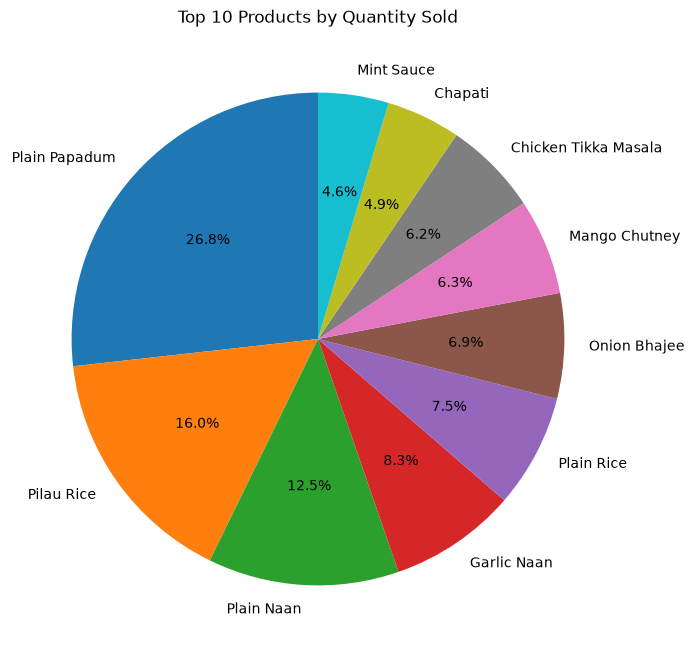

In [34]:
top_products = (
    df.groupby("product_name")["quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

plt.figure(figsize=(8, 8))

plt.pie(
    top_products,
    labels=top_products.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Top 10 Products by Quantity Sold")

plt.show()

# Task 2
Calculate `Item Price` (Product Price * Quantity) for each Order Item in dataframe.
And Make the same Top 10 pie chart, but this time by `Item Price`. So this chart should describe not the most popular products by quantity, but which products (top 10) make the most money for restaurant. It should be also with percentage.

In [35]:
df["item_price"] = df["product_price"] * df["quantity"]

print(df.head())

   id  quantity  order_id  product_id         product_name  product_price  \
0   1         2         1           6        Plain Papadum           0.80   
1   2         1         1         240     King Prawn Balti          12.95   
2   3         1         1          19          Garlic Naan           2.95   
3   4         1         1          36        Mushroom Rice           3.95   
4   5         1         1         111  Paneer Tikka Masala           8.95   

        order_datetime  item_price  
0  2019-08-03 20:25:00        1.60  
1  2019-08-03 20:25:00       12.95  
2  2019-08-03 20:25:00        2.95  
3  2019-08-03 20:25:00        3.95  
4  2019-08-03 20:25:00        8.95  


product_name
Chicken Tikka Masala    22133.35
Pilau Rice              18782.65
Plain Naan              12955.80
Korma                   12261.50
Bombay Aloo             10894.45
Onion Bhajee            10858.55
Butter Chicken          10626.60
Garlic Naan              9788.10
Korma - Chicken          9764.45
Plain Rice               8743.80
Name: item_price, dtype: float64


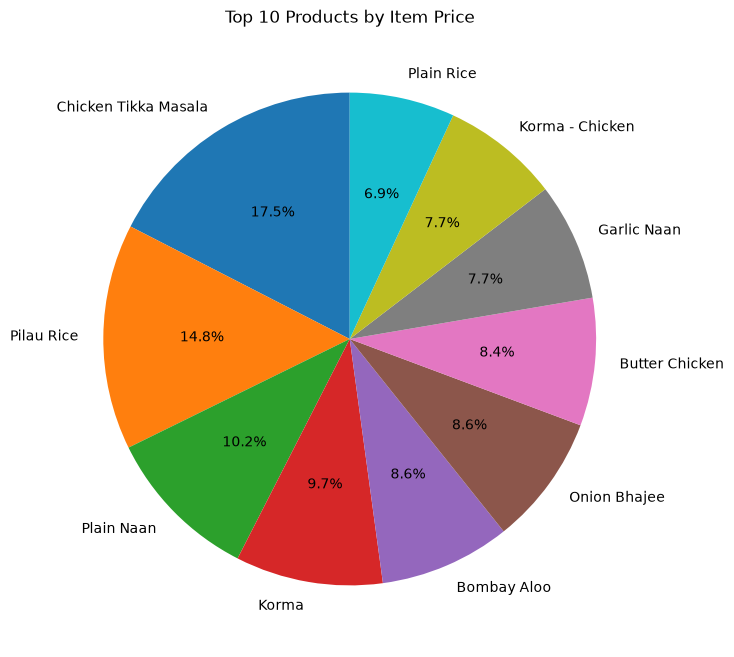

In [36]:
top_income = (
    df.groupby("product_name")["item_price"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_income)

plt.figure(figsize=(8, 8))

plt.pie(
    top_income,
    labels=top_income.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Top 10 Products by Item Price")

plt.show()

# Task 3
Calculate `Order Hour` based on `Order Datetime`, which will tell about the specific our the order was created (from 0 to 23). Using `Order Hour` create a bar chart, which will tell the total restaurant income based on the hour order was created. So on x-axis - it will be values from 0 to 23 (hours), on y-axis - it will be the total sum of order prices, which were sold on that hour.

Example:

![bar chart](../demo/bar.png)

id                         int64
quantity                   int64
order_id                   int64
product_id                 int64
product_name                 str
product_price            float64
order_datetime    datetime64[us]
item_price               float64
dtype: object
       order_datetime  order_hour
0 2019-08-03 20:25:00          20
1 2019-08-03 20:25:00          20
2 2019-08-03 20:25:00          20
3 2019-08-03 20:25:00          20
4 2019-08-03 20:25:00          20
order_hour
0        177.95
1         54.65
2        199.25
3          8.90
4         63.45
5         57.40
6        121.60
8        447.70
9        570.60
10      1250.35
11      3807.05
12     10565.85
13      8282.65
14      3343.55
15      3781.70
16     15634.75
17     72110.20
18    132462.50
19    109045.05
20     50218.25
21     21480.30
22     11001.50
23       373.25
Name: item_price, dtype: float64


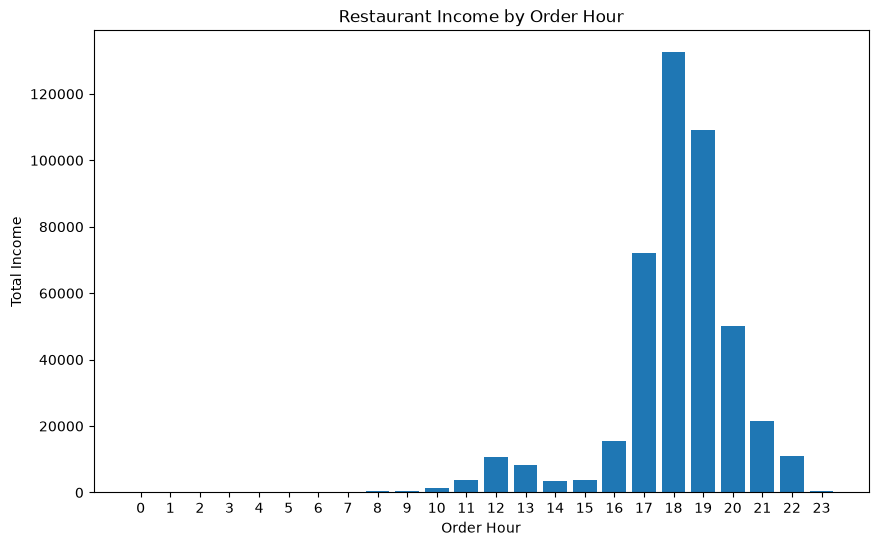

In [37]:
df["order_datetime"] = pd.to_datetime(df["order_datetime"])

print(df.dtypes)

df["order_hour"] = df["order_datetime"].dt.hour

print(df[["order_datetime", "order_hour"]].head())

hourly_income = (
    df.groupby("order_hour")["item_price"]
    .sum()
)

print(hourly_income)

plt.figure(figsize=(10, 6))

plt.bar(hourly_income.index, hourly_income.values)

plt.title("Restaurant Income by Order Hour")
plt.xlabel("Order Hour")
plt.ylabel("Total Income")

plt.xticks(range(24))

plt.show()

# Task 4
Make similar bar chart, but right now with `Order Day Of The Week` (from Monday to Sunday), and also analyze total restaurant income by each day of the week.

       order_datetime order_day
0 2019-08-03 20:25:00  Saturday
1 2019-08-03 20:25:00  Saturday
2 2019-08-03 20:25:00  Saturday
3 2019-08-03 20:25:00  Saturday
4 2019-08-03 20:25:00  Saturday
order_day
Monday        40008.30
Tuesday       38145.65
Wednesday     41246.20
Thursday      46021.55
Friday       100339.15
Saturday     112191.65
Sunday        67105.95
Name: item_price, dtype: float64


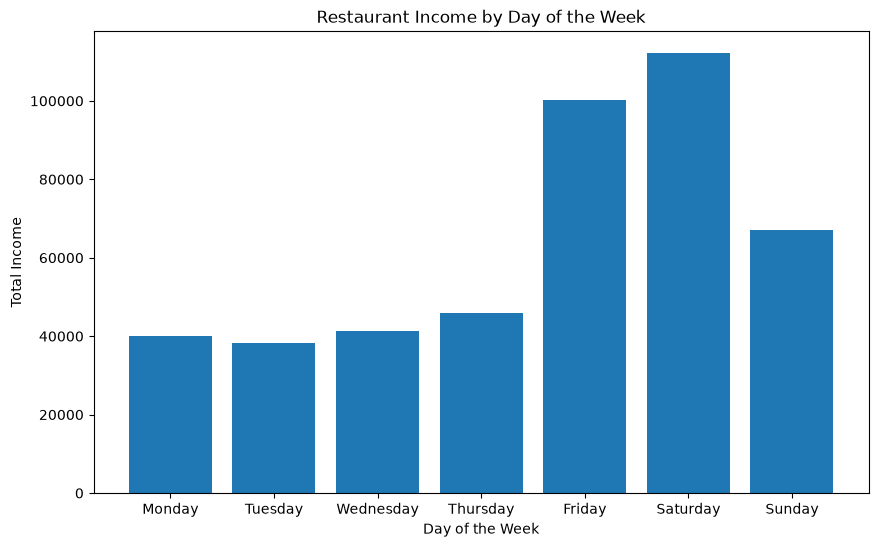

In [38]:
df["order_day"] = df["order_datetime"].dt.day_name()

print(df[["order_datetime", "order_day"]].head())

days_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

daily_income = (
    df.groupby("order_day")["item_price"]
    .sum()
    .reindex(days_order)
)

print(daily_income)

plt.figure(figsize=(10, 6))

plt.bar(daily_income.index, daily_income.values)

plt.title("Restaurant Income by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Total Income")

plt.show()